### $Loading\; Data$ ###

In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np
from textblob import TextBlob

# Load the data from the three sources
files = [
    "../data/nyt_ukraine_war_headlines.json",
    "../data/guardian_ukraine_war_headlines.json",
    "../data/bbc_ukraine_war_headlines.json"
]

all_rows = []

for file_name in files:
    with open(file_name, "r", encoding="utf-8") as f:
        data = json.load(f)  # data is {title: [date, url, journal], ...}
    
    # Convert each item to a dict with keys Title, Date, URL, Journal.
    for title, info_list in data.items():
        all_rows.append({
            "Title": title,
            "Date": info_list[0],
            "URL": info_list[1],
            "Journal": info_list[2]
        })

### $Sentiment\;Analysis$ ###

Could not parse date: Date not available
Could not parse date: Date not available
Could not parse date: Date not available
Could not parse date: Date not available
Could not parse date: Date not available
Could not parse date: Date not available
Could not parse date: Date not available
Could not parse date: Date not available
Could not parse date: Date not available
Could not parse date: Date not available
Could not parse date: Date not available
Could not parse date: Date not available
Could not parse date: Date not available
Could not parse date: Date not available
Could not parse date: Date not available
Could not parse date: Date not available
Could not parse date: Date not available
Could not parse date: Date not available
Could not parse date: Date not available
Could not parse date: Date not available
Could not parse date: Date not available
Could not parse date: Date not available
Could not parse date: Date not available
Could not parse date: Date not available
Could not parse 

C:\Users\lione\AppData\Local\Temp\ipykernel_37528\1264364422.py:99: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sentiment = df.set_index('Date').resample('M')['Sentiment_Polarity'].mean().reset_index()


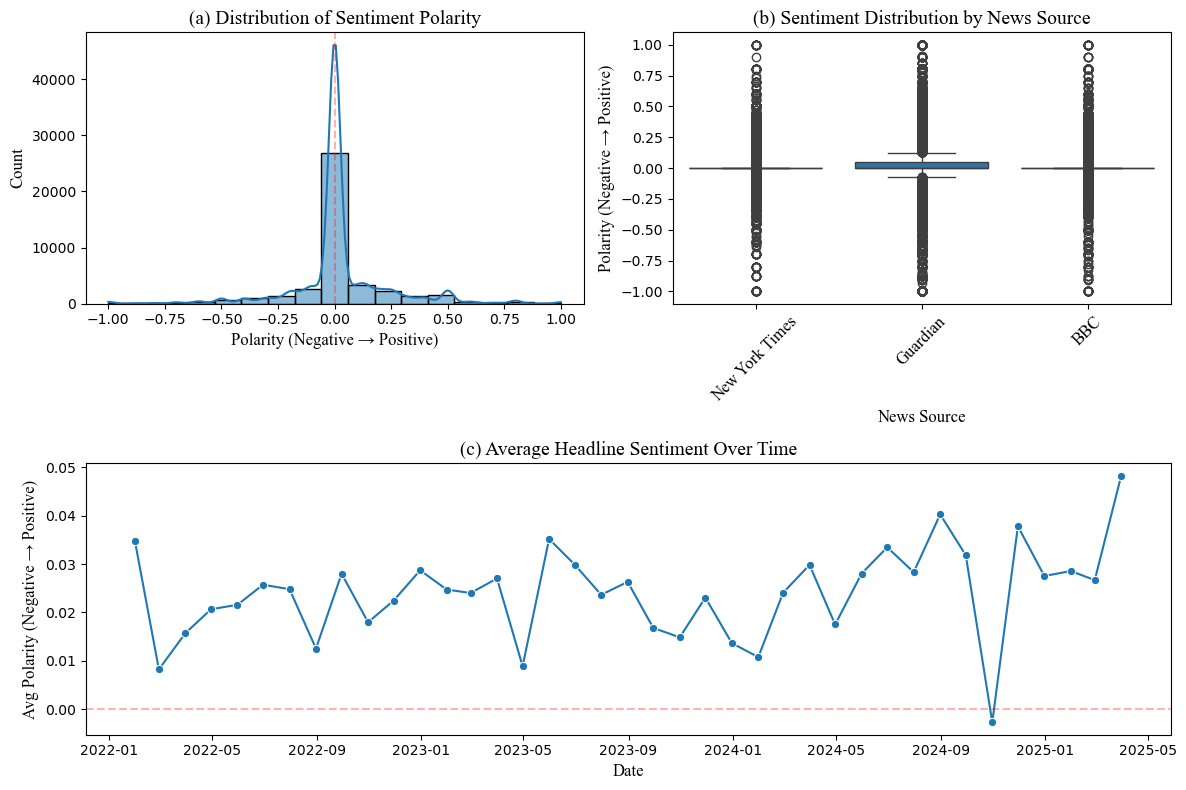


=== Most Positive Headlines ===
                                                                                                               Title  \
1665                                                        Once Best Friends, Bulgaria Takes a Stand Against Russia   
1679                                                                         What’s the Best Way to Treat Addiction?   
1824                                                     How Ukraine’s Greatest Novelist Is Fighting for His Country   
3713                                                   In a Ukraine Workshop, the Quest to Build the Perfect Grenade   
3778  Tinkering with tape, a scale and a 3-D printer, one Ukrainian unit is on a quest to build the perfect grenade.   

             Journal        Date  Sentiment_Polarity  
1665  New York Times  2022-05-11                 1.0  
1679  New York Times  2022-05-12                 1.0  
1824  New York Times  2022-05-24                 1.0  
3713  New York Times  2023

In [ ]:

# Create DataFrame
df = pd.DataFrame(all_rows)

# Function to handle relative date expressions like "7 days ago"
def convert_relative_dates(date_str):
    try:
        # First attempt direct conversion
        return pd.to_datetime(date_str)
    except:
        # Handle relative date expressions
        today = datetime.now()
        if isinstance(date_str, str):
            if "days ago" in date_str.lower() or "day ago" in date_str.lower():
                days = int(date_str.split()[0])
                return today - pd.Timedelta(days=days)
            elif "weeks ago" in date_str.lower():
                weeks = int(date_str.split()[0])
                return today - pd.Timedelta(weeks=weeks)
            elif "months ago" in date_str.lower():
                months = int(date_str.split()[0])
                # Approximate months as 30 days
                return today - pd.Timedelta(days=30*months)
            elif "hrs ago" in date_str.lower() or "hr ago" in date_str.lower() or "yesterday" in date_str.lower() or "mins ago" in date_str.lower():
                # For very recent articles, use yesterday's date
                return today - pd.Timedelta(days=1)
        
        # If all else fails, return NaT (Not a Time)
        print(f"Could not parse date: {date_str}")
        return pd.NaT

# Convert date strings to datetime objects, handling relative dates
df['Date'] = df['Date'].apply(convert_relative_dates)

# Drop rows with invalid dates
if df['Date'].isna().any():
    print(f"Dropped {df['Date'].isna().sum()} rows with unparseable dates")
    df = df.dropna(subset=['Date'])
    
# Filter to only include dates from January 1, 2022 onwards
start_date = pd.to_datetime('2022-01-01')
df_filtered = df[df['Date'] >= start_date]
print(f"Filtered from {len(df)} to {len(df_filtered)} headlines (dates from Jan 1, 2022 onwards)")
df = df_filtered

# Add sentiment analysis using TextBlob
def get_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity, blob.sentiment.subjectivity

# Apply sentiment analysis to each headline
df['Sentiment_Polarity'], df['Sentiment_Subjectivity'] = zip(*df['Title'].apply(get_sentiment))

# Create a new column for sentiment category
def categorize_sentiment(polarity):
    if polarity > 0.05:
        return "Positive"
    elif polarity < -0.05:
        return "Negative"
    else:
        return "Neutral"

df['Sentiment_Category'] = df['Sentiment_Polarity'].apply(categorize_sentiment)

# Display basic stats
print("Data Overview:")
print(f"Total headlines: {len(df)}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Sources: {', '.join(df['Journal'].unique())}")
print("\nSentiment Distribution:")
print(df['Sentiment_Category'].value_counts())
print("\nAverage sentiment by source:")
print(df.groupby('Journal')['Sentiment_Polarity'].mean())

# Save processed data
df.to_csv("headlines_with_sentiment.csv", index=False)

# Visualizations
plt.figure(figsize=(12, 8))

# 1. Distribution of sentiment polarity
plt.subplot(2, 2, 1)
sns.histplot(df['Sentiment_Polarity'], kde=True)
plt.title('(a) Distribution of Sentiment Polarity', font="Times New Roman", fontsize=14)
plt.xlabel('Polarity (Negative → Positive)', font="Times New Roman", fontsize=12)
plt.ylabel('Count', font="Times New Roman", fontsize=12)
plt.axvline(x=0, color='r', linestyle='--', alpha=0.3)

# 2. Sentiment by news source
plt.subplot(2, 2, 2)
sns.boxplot(x='Journal', y='Sentiment_Polarity', data=df)
plt.title('(b) Sentiment Distribution by News Source', font="Times New Roman", fontsize=14)
plt.xlabel('News Source', font="Times New Roman", fontsize=12)
plt.ylabel('Polarity (Negative → Positive)', font="Times New Roman", fontsize=12)
plt.xticks(rotation=45, font="Times New Roman", fontsize=12)

# 3. Sentiment over time
plt.subplot(2, 1, 2)
# Resample by month for clearer trends
monthly_sentiment = df.set_index('Date').resample('M')['Sentiment_Polarity'].mean().reset_index()
sns.lineplot(x='Date', y='Sentiment_Polarity', data=monthly_sentiment, marker='o')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)
plt.title('(c) Average Headline Sentiment Over Time', font="Times New Roman", fontsize=14)
plt.xlabel('Date', font="Times New Roman", fontsize=12)
plt.ylabel('Avg Polarity (Negative → Positive)', font="Times New Roman", fontsize=12)

plt.tight_layout()
plt.savefig('headline_sentiment_analysis.png', dpi=300)
plt.show()

# Additional analysis: Most extreme headlines
print("\n=== Most Positive Headlines ===")
pd.set_option('display.max_colwidth', None)
positive_headlines = df.nlargest(5, 'Sentiment_Polarity')[['Title', 'Journal', 'Date', 'Sentiment_Polarity']]
# Format the date to be more readable
positive_headlines['Date'] = positive_headlines['Date'].dt.strftime('%Y-%m-%d')
print(positive_headlines)

print("\n=== Most Negative Headlines ===")
pd.set_option('display.max_colwidth', None)
negative_headlines = df.nsmallest(5, 'Sentiment_Polarity')[['Title', 'Journal', 'Date', 'Sentiment_Polarity']]
# Format the date to be more readable
negative_headlines['Date'] = negative_headlines['Date'].dt.strftime('%Y-%m-%d')
print(negative_headlines)

# Compare sentiment between sources statistically
from scipy import stats

# Get data for each source
sources = df['Journal'].unique()
source_data = {source: df[df['Journal'] == source]['Sentiment_Polarity'] for source in sources}

# Run ANOVA if there are more than 2 sources
if len(sources) > 2:
    f_stat, p_value = stats.f_oneway(*[source_data[s] for s in sources])
    print(f"\nANOVA test for difference between sources: F={f_stat:.4f}, p={p_value:.4f}")
    if p_value < 0.05:
        print("There is a statistically significant difference in sentiment between sources.")
    else:
        print("No statistically significant difference in sentiment between sources.")
# Run t-test if there are exactly 2 sources
elif len(sources) == 2:
    t_stat, p_value = stats.ttest_ind(source_data[sources[0]], source_data[sources[1]])
    print(f"\nT-test for difference between {sources[0]} and {sources[1]}: t={t_stat:.4f}, p={p_value:.4f}")
    if p_value < 0.05:
        print("There is a statistically significant difference in sentiment between the two sources.")
    else:
        print("No statistically significant difference in sentiment between the two sources.")

In [133]:
# Additional analysis: Most extreme headlines by journal
print("\n=== Most Extreme Headlines By Journal ===")
journals = df['Journal'].unique()

for journal in journals:
    journal_data = df[df['Journal'] == journal]
    
    print(f"\n{journal} - Most Positive Headlines:")
    j_positive = journal_data.nlargest(3, 'Sentiment_Polarity')[['Title', 'Date', 'Sentiment_Polarity']]
    j_positive['Date'] = j_positive['Date'].dt.strftime('%Y-%m-%d')
    print(j_positive)
    
    print(f"\n{journal} - Most Negative Headlines:")
    j_negative = journal_data.nsmallest(3, 'Sentiment_Polarity')[['Title', 'Date', 'Sentiment_Polarity']]
    j_negative['Date'] = j_negative['Date'].dt.strftime('%Y-%m-%d')
    print(j_negative)


=== Most Extreme Headlines By Journal ===

New York Times - Most Positive Headlines:
                                                            Title        Date  \
1665     Once Best Friends, Bulgaria Takes a Stand Against Russia  2022-05-11   
1679                      What’s the Best Way to Treat Addiction?  2022-05-12   
1824  How Ukraine’s Greatest Novelist Is Fighting for His Country  2022-05-24   

      Sentiment_Polarity  
1665                 1.0  
1679                 1.0  
1824                 1.0  

New York Times - Most Negative Headlines:
                                                                   Title  \
63                                     I’m in Kyiv, and It Is Terrifying   
521  Videos show devastating strike at Mariupol hospital maternity ward.   
698    Impunity for War Crimes in Syria Casts a Grim Shadow Over Ukraine   

           Date  Sentiment_Polarity  
63   2022-02-25                -1.0  
521  2022-03-09                -1.0  
698  2022-03-15    

### $Preprocess\; Data$ ###

##### $Display\;first\; few\; data$ #####

In [4]:
import pandas as pd
import json

# Now your columns match the dict keys.
df = pd.DataFrame(all_rows, columns=["Title", "Date", "URL", "Journal"])

# Display the first few rows
print(df.head())


                                               Title        Date  \
0     Maps: Tracking the Russian Invasion of Ukraine  2022-02-14   
1                 Putin Is Making a Historic Mistake  2022-02-23   
2  Climate Fears on Back Burner as Fuel Costs Soa...  2022-02-23   
3  ‘A Time of Worries’: New York City’s Ukrainian...  2022-02-23   
4  Russia Could Use Cryptocurrency to Blunt the F...  2022-02-23   

                                                 URL         Journal  
0  https://www.nytimes.com/interactive/2022/world...  New York Times  
1  https://www.nytimes.com/2022/02/23/opinion/put...  New York Times  
2  https://www.nytimes.com/2022/02/23/business/ec...  New York Times  
3  https://www.nytimes.com/2022/02/23/nyregion/ny...  New York Times  
4  https://www.nytimes.com/2022/02/23/business/ru...  New York Times  


#### $Generate\;headlines\;frequency\;by\;different\;medias$ ####

Total number of headlines: 43338

Headlines count by journal:
Journal
Guardian          27749
BBC                8388
New York Times     7201
Name: count, dtype: int64


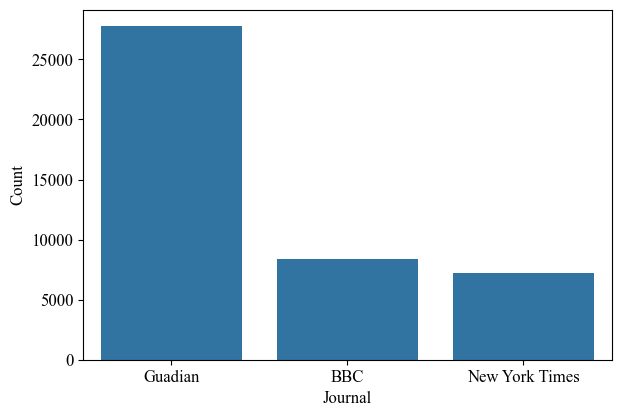

In [5]:
# Display basic information
print(f"Total number of headlines: {len(df)}")
journal_counts = df['Journal'].value_counts()
print("\nHeadlines count by journal:")
print(journal_counts)

# Create a figure with multiple plots
plt.figure(figsize=(15, 10))

# Plot 1: Bar chart of headline counts by journal
plt.subplot(2, 2, 1)
sns.barplot(x=["Guadian", "BBC", "New York Times"], y=journal_counts.values)
plt.ylabel('Count', font="Times New Roman", fontsize=12)
plt.xlabel('Journal', font="Times New Roman", fontsize=12)
plt.xticks(font = "Times New Roman", fontsize=12)
plt.yticks(font = "Times New Roman", fontsize=12)

plt.savefig('headline_word_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

### $Natural\;Language\;Processing$ ###

In [6]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lione\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lione\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lione\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [7]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
# Make sure these are downloaded at least once in your environment:
# nltk.download('stopwords')
# nltk.download('punkt')
# nltk.download('averaged_perceptron_tagger')  # For POS tagging
stop_words = set(stopwords.words('english'))

## Name Dictionary
# Multi-word name references
names_dict_full = {
    r"\bjoe\s+biden\b": "joe_biden",
    r"\bdonald\s+trump\b": "donald_trump",
    r"\bvladimir\s+putin\b": "vladimir_putin",
    r"\bxi\s+jinping\b": "xi_jinping",
    r"\bking\s+charles\b": "king_charles",
    r"\bqueen\s+elizabeth\b": "queen_elizabeth",
    r"\bursula\s+von\s+der\s+leyen\b": "ursula_von_der_leyen",
    r"\bjustin\s+trudeau\b": "justin_trudeau",
    r"\bemmanuel\s+macron\b": "emmanuel_macron",
    r"\belizabeth\s+truss\b": "elizabeth_truss",
    r"\bkeir\s+starmer\b": "keir_starmer",
    r"\bboris\s+johnson\b": "boris_johnson",
    r"\bvolodymyr\s+zelensky\b": "volodymyr_zelensky",
    r"\balexei\s+navalny\b": "alexei_navalny",
    r"\brishi\s+sunak\b": "rishi_sunak",
    r"\bmike\s+johnson\b": "mike_johnson"
}

# Single-word references that map to the same major code
names_dict_single = {
    r"\bjoe\b": "joe_biden",
    r"\bbiden\b": "joe_biden",
    r"\bdonald\b": "donald_trump",
    r"\btrump\b": "donald_trump",
    r"\bvladimir\b": "vladimir_putin",
    r"\bputin\b": "vladimir_putin",
    r"\bxi\b": "xi_jinping",
    r"\bcharles\b": "king_charles",
    r"\belizabeth\b": "queen_elizabeth",
    r"\bursula\b": "ursula_von_der_leyen",
    r"\bvon\s+der\s+leyen\b": "ursula_von_der_leyen",
    r"\bboris\b": "boris_johnson",
    r"\bzelensky\b": "volodymyr_zelensky",
    r"\bnavalny\b": "alexei_navalny",
    r"\bsunak\b": "rishi_sunak",
    r"\bmacron\b": "emmanuel_macron",
    r"\btrudeau\b": "justin_trudeau",
    r"\bstarmer\b": "keir_starmer",
    r"\btruss\b": "elizabeth_truss",
    r"\bwagner\b": "wagner_group",
    r"\bPrigozhin\b": "yevgeny_prigozhin",
    r"\bLukashenko\b": "alexander_lukashenko",
    r"\byevegeny\b": "yevgeny_prigozhin",
    r"\bgerasimov\b": "valery_gerasimov",
    r"\bmodi\b": "narendra_modi",
    r"\bmerkel\b": "angela_merkel",
    r"\bscholz\b": "olaf_scholz",
    r"\bmerz\b": "friedrich_merz",
    r"\btory\b": "conservative_party",
    r"\blabour\b": "labour_party",
    r"\bconservatives\b": "conservative_party",
    r"\blabourites\b": "labour_party",
    r"\bpm\b": "prime_minister",
    r"\bjohnson\b": "Mike Johnson"

}

abbreviations = {
    r"\buk\b": "united_kingdom",
    r"\bus\b": "united_states",
    r"\busa\b": "united_states",
    r"\bun\b": "united_nations",
    r"\beu\b": "european_union"
}

# Additional low-information words to remove
custom_low_info = {"new", "day", "first", "could", "u", "review", "glance", "guardian", "nyt", "bbc", "news", "editorial", "far", "mail", "morning", 
                   "must", "night", "one", "people", "post", "read", "say", "see", "time", "today", "tomorrow", "tonight", "week", "year", "yesterday", "world",
                   "call", "white", "power", "view", "live", "watch", "back", "front", "page", "good", "bad", "great", "best", "worst", "top", "bottom", "high", 
                   "low", "iseraeli", "court", "fight", "state", "party", "thing", "way", "end", "start", "big", "small", "large", "huge", "tiny", "old", "new"}

def unify_person_names(text, full_map, single_map):
    """
    1) Collapse multi-word person references into a single token.
    2) Collapse single-word references to the same entity.
    """
    # --- Pass 1: Multi-word names ---
    for pattern, replacement in full_map.items():
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    
    # --- Pass 2: Single-word references ---
    for pattern, replacement in single_map.items():
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    
    return text

def remove_verbs(tokens):
    """
    Remove any token recognized as a verb (VB, VBD, VBG, VBN, VBP, VBZ).
    """
    tagged = nltk.pos_tag(tokens)
    filtered = [word for (word, tag) in tagged if not tag.startswith('VB')]
    return filtered

def preprocess_text(text, remove_all_verbs=True):
    """
    Preprocesses text by lowercasing, unifying names, removing punctuation,
    and filtering stopwords and verbs.
    """
    # 1) Lowercase
    text = text.lower()
    
    # 2) Unify person names - IMPORTANT: do this BEFORE tokenization
    text = unify_person_names(text, names_dict_full, names_dict_single)
    
    # 3) Also unify abbreviations if needed
    for pattern, replacement in abbreviations.items():
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    
    # 4) Remove punctuation, digits, etc., leaving only letters and spaces
    text = re.sub(r'[^a-z_\s]+', ' ', text)  # Note: added underscore to preserve name_tokens
    
    # 5) Tokenize
    tokens = word_tokenize(text)
    
    # 6) Remove standard stopwords (e.g., "the", "and", "of", ...)
    tokens = [t for t in tokens if t not in stop_words]
    
    # 7) Remove verbs if specified
    if remove_all_verbs:
        tokens = remove_verbs(tokens)
    
    # 8) Remove custom low info words
    tokens = [t for t in tokens if t not in custom_low_info]
    
    return tokens

# Apply the preprocessing to your dataframe
df['tokens'] = df['Title'].apply(preprocess_text)


In [8]:
from collections import Counter
# Now count tokens
all_tokens = [token for tokens_list in df['tokens'] for token in tokens_list]
word_counts = Counter(all_tokens)
most_common_words = word_counts.most_common(20)
print(most_common_words)

[('ukraine', 9586), ('war', 6496), ('russia', 5200), ('russian', 3385), ('united_kingdom', 2439), ('vladimir_putin', 2326), ('united_states', 1904), ('ukrainian', 1622), ('donald_trump', 1603), ('joe_biden', 1342), ('invasion', 1013), ('israel', 996), ('gaza', 945), ('energy', 784), ('crisis', 764), ('attack', 664), ('european_union', 655), ('aid', 636), ('nuclear', 630), ('europe', 609)]


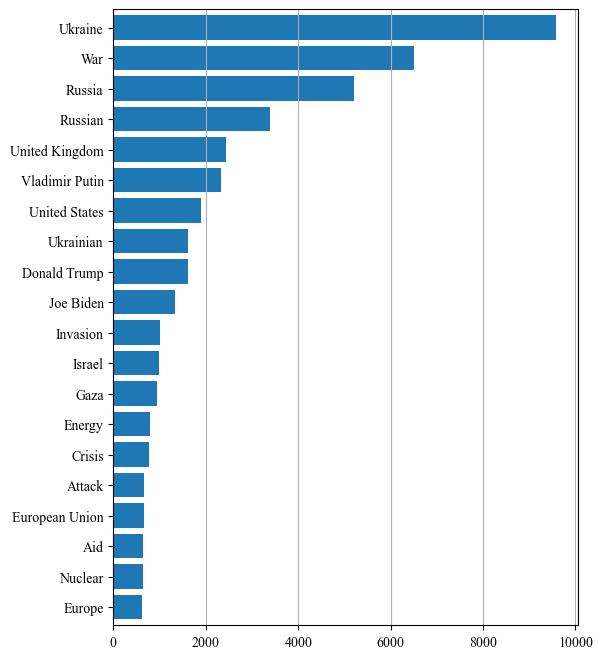

In [9]:
import matplotlib.pyplot as plt

words, counts = zip(*most_common_words)
# remove the underscores from the tokens
words = [word.replace("_", " ").title() for word in words]
# reverse the order of the words and counts
words = list(reversed(words))
counts = list(reversed(counts))

plt.figure(figsize=(6, 8))
bars = plt.barh(words, counts)
for bar, name in zip(bars, words):
    bar.set_label(name)
ax = plt.gca()

plt.grid(axis='x')
# adjust y axis margin to make the plot more compact
plt.gca().margins(y=0.01)

plt.yticks(fontsize=20, font='Times New Roman')
plt.xticks(fontsize=20, font='Times New Roman')
plt.savefig("top_words.png", bbox_inches='tight')
plt.show()


In [ ]:
# Display the tokens column
df["tokens"]

0                       [maps, russian, invasion, ukraine]
1                      [vladimir_putin, historic, mistake]
2        [climate, fears, fuel, costs, russia, crisis, ...
3                [york, city, ukrainians, anxious, afraid]
4        [russia, cryptocurrency, blunt, force, sanctions]
                               ...                        
43333      [russia, genocide, ukraine, volodymyr_zelensky]
43334           [poland, army, generals, ahead, key, vote]
43335      [gangs, vow, de, escalate, ukraine, cyber, war]
43336                           [ancient, ukraine, battle]
43337                   [tough, choice, ukraine, children]
Name: tokens, Length: 43338, dtype: object

##### $LDA$ #####

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

def dummy_tokenizer(doc):
    # doc is assumed to be a preprocessed list of tokens already
    # but scikit-learn wants a single string, so we can join them
    return doc

# Because our 'tokens' column is already processed, 
# we can pass them to CountVectorizer with a 'dummy' tokenizer:
vectorizer = CountVectorizer(
    tokenizer=lambda x: x,  # we already have tokens
    preprocessor=lambda x: x # no pre-processing needed
)

# Fit on tokens and transform
dtm = vectorizer.fit_transform(df['tokens'])


In [13]:
from sklearn.decomposition import LatentDirichletAllocation

num_topics = 5  # you can choose the number of topics
lda_model = LatentDirichletAllocation(
    n_components=num_topics,
    random_state=42
)
lda_model.fit(dtm)


LatentDirichletAllocation(n_components=5, random_state=42)

##### $Topic Modeling$ #####

In [15]:
def print_topics(model, vectorizer, top_n=10):
    feature_names = vectorizer.get_feature_names_out()
    for idx, topic in enumerate(model.components_):
        print(f"Topic {idx}:")
        # topic is an array of shape (vocab_size,)
        # argsort in descending order to get top words
        top_indices = topic.argsort()[::-1][:top_n]
        top_features = [feature_names[i] for i in top_indices]
        top_scores = [topic[i] for i in top_indices]
        print("  ".join([f"{word}({int(score)})" for word, score in zip(top_features, top_scores)]))
        print()

print_topics(lda_model, vectorizer)


Topic 0:
united_kingdom(562)  prime_minister(484)  donald_trump(452)  european_union(448)  global(417)  china(389)  oil(346)  gas(337)  nato(293)  keir_starmer(281)

Topic 1:
ukraine(6378)  war(3524)  russia(2601)  vladimir_putin(1568)  russian(1091)  joe_biden(507)  united_states(470)  kyiv(464)  military(444)  zelenskiy(389)

Topic 2:
war(830)  donald_trump(803)  israel(801)  gaza(718)  joe_biden(715)  united_states(536)  election(387)  united_kingdom(332)  hamas(327)  bank(250)

Topic 3:
ukraine(3207)  russia(2429)  russian(2272)  war(2102)  ukrainian(1611)  invasion(827)  nuclear(630)  vladimir_putin(599)  united_kingdom(581)  united_states(521)

Topic 4:
united_kingdom(764)  energy(706)  years(395)  prices(308)  wars(300)  crisis(268)  price(220)  food(204)  united_states(204)  elizabeth_truss(202)



In [16]:
import pandas as pd

def get_topic_word_df(lda_model, vectorizer, top_n=10):
    feature_names = vectorizer.get_feature_names_out()
    rows = []

    for topic_idx, topic in enumerate(lda_model.components_):
        # Sort descending by weight
        top_indices = topic.argsort()[::-1][:top_n]
        
        for rank, idx in enumerate(top_indices):
            word = feature_names[idx]
            weight = topic[idx]
            rows.append({
                "topic": topic_idx,
                "word": word,
                "weight": weight
            })

    return pd.DataFrame(rows)

df_topics = get_topic_word_df(lda_model, vectorizer, top_n=10)
df_topics.head()

,topic,word,weight
0,0,united_kingdom,562.285586
1,0,prime_minister,484.188054
2,0,donald_trump,452.812466
3,0,european_union,448.178299
4,0,global,417.255920


In [17]:
df_matrix = df_topics.pivot_table(
    index="word", 
    columns="topic", 
    values="weight",
    fill_value=0.0
)

# Sort words or topics if you want a specific order:
df_matrix = df_matrix.sort_values(by=df_matrix.columns.tolist(), ascending=False, axis=0)

df_matrix.head()

topic,0,1,2,3,4
word,,,,,
united_kingdom,562.285586,0.0,332.849789,581.028987,764.124895
prime_minister,484.188054,0.0,0.000000,0.000000,0.000000
donald_trump,452.812466,0.0,803.306159,0.000000,0.000000
european_union,448.178299,0.0,0.000000,0.000000,0.000000
global,417.255920,0.0,0.000000,0.000000,0.000000


In [18]:
df_melted = df_matrix.reset_index().melt(
    id_vars="word",
    var_name="topic",
    value_name="weight"
)
# Now each row is (word, topic, weight).
# We only plot rows with weight > 0.
df_melted = df_melted[df_melted["weight"] > 0]
df_melted.head()

,word,topic,weight
0,united_kingdom,0,562.285586
1,prime_minister,0,484.188054
2,donald_trump,0,452.812466
3,european_union,0,448.178299
4,global,0,417.255920


##### $Topic\; Modeling\; Visualization$ #####

###### $Data\;Prep$ ######

In [ ]:
import pandas as pd
import altair as alt
import numpy as np

# This function calculates topic-specific word frequencies directly from the document-term matrix
# (Your existing get_topic_word_frequencies function remains unchanged)
def get_topic_word_frequencies(df_topics, dtm, vectorizer, lda_model):
    """
    Calculate word frequencies per topic using document-topic distributions
    """
    # Get document-topic distributions
    doc_topic_dist = lda_model.transform(dtm)
    
    # Get feature names (vocabulary)
    feature_names = vectorizer.get_feature_names_out()
    
    # Convert sparse DTM to dense array for easier calculations
    dtm_array = dtm.toarray()
    
    # Dictionary to store word frequencies by topic
    topic_word_freq = {}
    
    # For each topic
    for topic_idx in range(lda_model.n_components):
        # Weight each document by its probability of belonging to this topic
        topic_weights = doc_topic_dist[:, topic_idx].reshape(-1, 1)
        
        # Multiply document-term matrix by topic weights
        # This gives us weighted word counts for this topic
        weighted_dtm = dtm_array * topic_weights
        
        # Sum across documents to get total weighted frequency for each word in this topic
        topic_term_freqs = weighted_dtm.sum(axis=0)
        
        # Create a dictionary mapping words to their weighted frequencies in this topic
        word_freqs = {feature_names[i]: freq for i, freq in enumerate(topic_term_freqs)}
        
        # Store in our dictionary
        topic_word_freq[topic_idx] = word_freqs
    
    # Add frequency to df_topics
    df_topics['frequency'] = df_topics.apply(
        lambda row: topic_word_freq[row['topic']].get(row['word'], 0), 
        axis=1
    )
    
    return df_topics

# First get the topic words and weights
df_topics = get_topic_word_df(lda_model, vectorizer, top_n=10)

# Then add topic-specific word frequencies
df_topics = get_topic_word_frequencies(df_topics, dtm, vectorizer, lda_model)

# Preprocess the words: convert to title case and remove underscores
df_topics['word'] = df_topics['word'].str.title().str.replace('_', ' ')

# We'll use the same merged DataFrame but group by word for the bar chart
# Since we've already processed the words in df_topics, 
# the groupby will use the title-cased, underscore-removed words
df_word_freq = df_topics.groupby('word', as_index=False)['frequency'].sum()

# Set a random seed for reproducibility
np.random.seed(42)

# Get the list of words and randomize their order
words = df_word_freq['word'].tolist()
np.random.shuffle(words)

# Create a categorical ordering for the words
word_order = pd.Categorical(df_word_freq['word'], categories=words, ordered=True)

# Add this order back to our dataframes
df_word_freq['word_order'] = pd.Categorical(df_word_freq['word'], categories=words, ordered=True)
df_word_freq = df_word_freq.sort_values('word_order')

# Also add to df_topics
df_topics['word_order'] = pd.Categorical(df_topics['word'], categories=words, ordered=True)
df_topics = df_topics.sort_values('word_order')

# IMPORTANT: To make shared y-axis work, both charts need to use the same data source for the y-axis
# Create a domain for the word field that includes all words in correct order
word_order = df_word_freq['word'].tolist()

__primary plot__

In [84]:
# Modify the bubble chart to use our explicit ordering
bubble_chart = (
    alt.Chart(df_topics)
    .mark_circle()
    .encode(
        # X-axis: place labels at the top and rename topics
        x=alt.X(
            'topic:O',
            title=None,
            axis=alt.Axis(
                orient='top',
                labelAngle=45,
                grid=True,
                labelExpr='{"0":"Topic 1", "1":"Topic 2", "2":"Topic 3", "3":"Topic 4", "4":"Topic 5"}[datum.value]'
            )
        ),
        # Y-axis: use our explicit word ordering
        y=alt.Y(
            'word:N',
            title=None,
            sort=None,  # Use data order, don't let Altair re-sort
            axis=alt.Axis(grid=True)
        ),
        # Use topic-specific frequencies for sizing
        size=alt.Size(
            'frequency:Q', 
            title='Topic-Specific Frequency', 
            scale=alt.Scale(range=[0, 500])
        ),
        color=alt.Color(
            'topic:N', 
            legend=None,
            scale=alt.Scale(scheme='category10')
        ),
        tooltip=['topic:O', 'word:O', 'weight:Q', 'frequency:Q']
    )
    .properties(
        width=alt.Step(25),
        height=500
    )
)

bubble_chart

c:\Users\lione\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.Chart(...)

__secondary plot__

In [ ]:

bar_chart = (
    alt.Chart(df_word_freq)
    .mark_bar()
    .encode(
        y=alt.Y(
            'word:N', 
            sort=None,  # Use data order, don't let Altair re-sort
            title='',  
            axis=alt.Axis(grid=False)
        ),
        x=alt.X(
            'frequency:Q', 
            title='',
            axis=alt.Axis(
                grid=False, 
                labelExpr="datum.value > 0 ? datum.label : ''"  # Hide the zero label
            )
        ),
        color=alt.Color(
            'frequency:Q',
            scale=alt.Scale(scheme='viridis'),
            legend=None
        )
    )
    .properties(
        width=40,
        height=160,
        title="Word Frequency"  # Add title to the chart
    )
)

# Combine the charts with a shared y-axis
final_chart = alt.hconcat(
    bubble_chart, 
    bar_chart
).resolve_scale(
    y='shared'  # Share the y-axis scale
).configure_view(
    strokeWidth=0  # Remove the border
).configure_text(
    font='Times New Roman',  # Set font for all text
    fontSize=12  # Set base font size
).configure_axis(
    labelFont='Times New Roman',  # Set font for axis labels
    titleFont='Times New Roman',  # Set font for axis titles
    labelFontSize=12,
    titleFontSize=14
)

c:\Users\lione\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.Chart(...)

__final plot__

In [80]:
final_chart

c:\Users\lione\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
c:\Users\lione\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.HConcatChart(...)

In [81]:
final_chart.save("topic_word_frequency.html")

c:\Users\lione\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
c:\Users\lione\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
